# Quick start example
This is a quick start example showing how to set up and run a
Direct Column breakthrough adsorption simulation using predefined input parameters.
The example uses some utility functions which simplify the simulation setup.
To see the steps used in more detail, please refer to the
[Simulate DCB](simulate_DCB.md) example.

# Load the Mocca module

In [1]:
using Mocca

# Import input parameters
We import and run a DCB adsorption simulation from a JSON file.

Setup filepath to JSON input

In [2]:
json_dir = joinpath(dirname(pathof(Mocca)), "../models/json/")

"/home/runner/work/Mocca.jl/Mocca.jl/src/../models/json/"

Load input parameters from JSON

In [3]:
filepath = joinpath(json_dir, "haghpanah_DCB_input_simple.json")
(constants, info ) = Mocca.parse_input(filepath)

(Mocca.adsorptionConstants{Float64}
  molecularMassOfCO2: Float64 0.04401
  molecularMassOfN2: Float64 0.028
  R: Float64 8.3144598
  Φ: Float64 0.37
  b0: StaticArraysCore.SVector{2, Float64}
  d0: StaticArraysCore.SVector{2, Float64}
  ΔUbi: StaticArraysCore.SVector{2, Float64}
  ΔUdi: StaticArraysCore.SVector{2, Float64}
  qsbi: StaticArraysCore.SVector{2, Float64}
  qsdi: StaticArraysCore.SVector{2, Float64}
  ϵ_p: Float64 0.35
  D_m: Float64 1.6e-5
  τ: Float64 3.0
  d_p: Float64 0.002
  ρ_s: Float64 1130.0
  C_ps: Float64 1070.0
  V0_inter: Float64 1.0
  fluid_viscosity: Float64 1.72e-5
  K_z: Float64 0.0903
  K_w: Float64 16.0
  ρ_g: Float64 1.22638310956
  C_pg: StaticArraysCore.SVector{2, Float64}
  C_pa: StaticArraysCore.SVector{2, Float64}
  r_in: Float64 0.1445
  r_out: Float64 0.162
  h_in: Float64 0.0
  h_out: Float64 0.0
  ρ_w: Float64 7800.0
  C_pw: Float64 502.0
  T_a: Float64 298.15
  v_feed: Float64 0.37
  y_feed: StaticArraysCore.SVector{2, Float64}
  p_high: Float6

# Option 2: Load input from the detailed JSON format

filepath = joinpath(json_dir, "haghpanah_DCB_input.json")
(constants, info ) = Mocca.parse_input(filepath)

# Option 3: Get input pars from a predefined Julia dictionary
(constants, info )= Mocca.parse_input(haghpanah_DCB_input())

# Setup simulation case and timestep configuration

In [4]:
case, ts_config = Mocca.setup_mocca_case(constants, info)

(Jutul.JutulCase(Jutul.SimulationModel{Jutul.DiscretizedDomain{JutulDarcy.MinimalTPFATopology{Matrix{Int64}}, @NamedTuple{mass_flow::Jutul.PotentialFlow{:generic, Vector{Jutul.TPFA{Int64}}, Vector{Jutul.SPU{Int64}}, @NamedTuple{cells::Vector{Int64}, faces::Vector{Int64}, face_pos::Vector{Int64}, face_sign::Vector{Int64}}}, heat_flow::Jutul.PotentialFlow{:generic, Vector{Jutul.TPFA{Int64}}, Vector{Jutul.SPU{Int64}}, @NamedTuple{cells::Vector{Int64}, faces::Vector{Int64}, face_pos::Vector{Int64}, face_sign::Vector{Int64}}}}, Dict{Jutul.JutulEntity, Int64}, Jutul.TrivialGlobalMap}, TwoComponentAdsorptionSystem{Mocca.adsorptionConstants{Float64}, Float64}, Jutul.FullyImplicitFormulation, Jutul.DefaultContext}(DiscretizedDomain with MinimalTPFATopology (200 cells, 199 faces) and discretizations for mass_flow, heat_flow
, TwoComponentAdsorptionSystem{Mocca.adsorptionConstants{Float64}, Float64}
  component_names: Array{String}((2,))
  permeability: Float64 3.403241790543378e-9
  dispersion: 

#Run simulation

In [5]:
states, timesteps = Mocca.simulate_process(case; timestep_selector_cfg = ts_config,
    output_substates = true, info_level = 0)

Jutul: Simulating 1 hour, 23.33 minutes as 1 report steps
╭────────────────┬──────────┬───────────────┬──────────╮
│ Iteration type │ Avg/step │  Avg/ministep │    Total │
│                │  1 steps │ 301 ministeps │ (wasted) │
├────────────────┼──────────┼───────────────┼──────────┤
│ Newton         │    612.0 │       2.03322 │  612 (0) │
│ Linearization  │    913.0 │       3.03322 │  913 (0) │
│ Linear solver  │    612.0 │       2.03322 │  612 (0) │
│ Precond apply  │      0.0 │           0.0 │    0 (0) │
╰────────────────┴──────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬─────────╮
│ Timing type   │    Each │   Relative │   Total │
│               │      ms │ Percentage │       s │
├───────────────┼─────────┼────────────┼─────────┤
│ Properties    │  0.0574 │     0.30 % │  0.0352 │
│ Equations     │  4.1597 │    32.46 % │  3.7978 │
│ Assembly      │  0.4973 │     3.88 % │  0.4541 │
│ Linear solve  │  4.8848 │    25.55 % │  2.9895 │
│ Linear setup  │  0.

(OrderedCollections.OrderedDict{Symbol, Any}[OrderedCollections.OrderedDict(:Pressure => [103327.06357747625, 103317.2951612046, 103307.1315408171, 103296.556830907, 103285.55564447165, 103274.12134140026, 103262.25545643525, 103249.96625886434, 103237.26736346117, 103224.17648339109  …  100165.92485761229, 100148.50003862799, 100131.06586255471, 100113.62223043108, 100096.16904317123, 100078.70620156411, 100061.23360627265, 100043.7511578331, 100026.25875665428, 100008.75630301645], :y => [0.12968607298882429 0.1031975620785496 … 1.017790540704525e-10 1.016764543545366e-10; 0.8703139270111758 0.8968024379214504 … 0.9999999998982209 0.9999999998983236], :AdsorbedConcentration => [144.72070169365242 116.06196353062978 … 3.111794370243393e-5 3.1117811201852104e-5; 36.53911530529432 45.25856136407987 … 370.5155837604913 370.4717479165543], :Temperature => [299.7442607296394, 299.36363899037843, 298.765767490933, 298.27954413563026, 297.9162568928604, 297.654911128762, 297.4746822846642, 2

# Export results to CSV

In [6]:
Mocca.export_cell_results(joinpath(Mocca.moccaResultsDir, "haghpanah_DCB_results.csv"),
    case, states, timesteps; format="csv")

# Plot results at the outlet

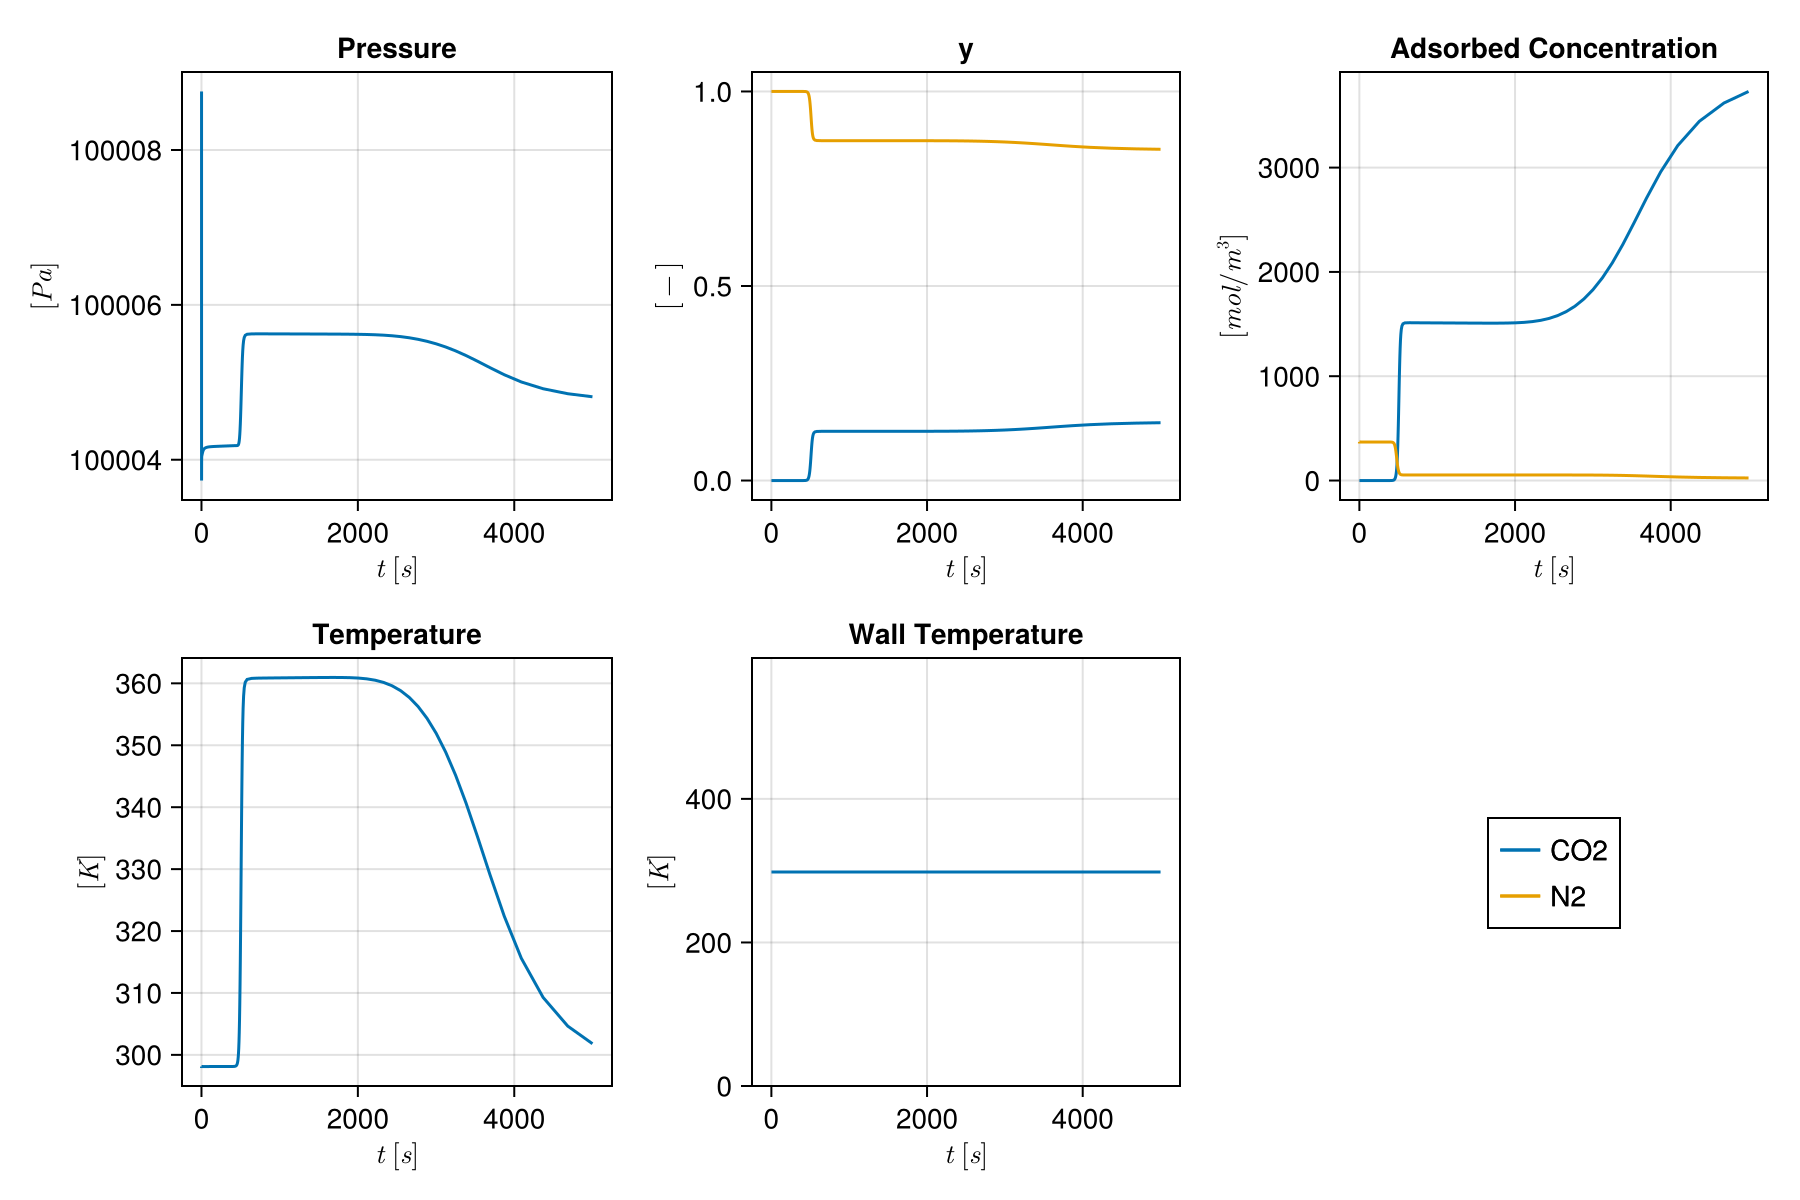

CairoMakie.Screen{IMAGE}


In [7]:
f = Mocca.plot_outlet(case, states, timesteps)
display(f)

## Example on GitHub
If you would like to run this example yourself, it can be downloaded from [the Mocca.jl GitHub repository](https://github.com/sintefmath/Mocca.jl/blob/main/examples/quick_start.jl).

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*